# Context Data Distribution Analysis

Descriptive audit of the verb–noun pair dataset before inferential modelling.

- Source: two CSV outputs from the Sketch Engine / embedding pipeline
- `output/verbs.csv` — pairs queried by verb
- `output/nouns.csv` — pairs queried by noun
- No `.pt` files are loaded here; all analysis uses the CSV metadata.

## Analysis roadmap
1. Load and combine both CSVs; clean "Not found" values.
2. Dataset overview: pair counts, unique verbs/nouns, source overlap.
3. Missing data audit (Sketch Engine coverage).
4. Descriptive statistics for all numeric variables.
5. Distribution plots by query source.
6. SND profiles across neighbourhood sizes.
7. Export combined CSV, stats JSON, and plots.

In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
VERBS_CSV  = ROOT / 'output' / 'verbs.csv'
NOUNS_CSV  = ROOT / 'output' / 'nouns.csv'
EXPORT_DIR = ROOT / 'output' / 'notebook_exports'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
print('VERBS_CSV exists:', VERBS_CSV.exists())
print('NOUNS_CSV exists:', NOUNS_CSV.exists())
print('EXPORT_DIR:', EXPORT_DIR)

In [14]:
NUMERIC_COLS = [
    'n_kwics', 'coll_freq', 'logDice',
    'noun_concreteness', 'noun_synset_len', 'verb_synset_len',
    'snd3', 'snd10', 'snd25', 'snd50',
    'n_nouns_for_verb', 'n_verbs_for_noun',
]

verbs_df = pd.read_csv(VERBS_CSV)
nouns_df = pd.read_csv(NOUNS_CSV)

verbs_df['source'] = 'queried_by_verb'
nouns_df['source'] = 'queried_by_noun'

df = pd.concat([verbs_df, nouns_df], ignore_index=True)

# Replace Sketch Engine "Not found" sentinel with NaN
for col in ['coll_freq', 'logDice', 'usage']:
    df[col] = df[col].replace('Not found', pd.NA)

for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Total rows:  {len(df):,}')
print(f'Columns:     {list(df.columns)}')
df.head()

Total rows:  23,818
Columns:     ['verb', 'noun', 'item', 'n_kwics', 'coll_freq', 'logDice', 'usage', 'noun_concreteness', 'noun_synset_len', 'verb_synset_len', 'snd3', 'snd10', 'snd25', 'snd50', 'queried_by_verb', 'queried_by_noun', 'n_nouns_for_verb', 'n_verbs_for_noun', 'source']


,verb,noun,item,n_kwics,coll_freq,logDice,usage,noun_concreteness,noun_synset_len,verb_synset_len,snd3,snd10,snd25,snd50,queried_by_verb,queried_by_noun,n_nouns_for_verb,n_verbs_for_noun,source
0,abandon,animal,abandon animal,100,2542.0,5.05,abandoned animals,4.61,1,5,176.69,244.80,282.95,316.08,1,0,99,7,queried_by_verb
1,abandon,approach,abandon approach,100,3257.0,4.60,abandoned this approach,2.74,9,5,228.24,334.77,377.46,398.77,1,0,99,6,queried_by_verb
2,abandon,area,abandon area,100,4080.0,4.06,abandoned areas,3.72,6,5,263.68,404.24,463.02,501.91,1,0,99,24,queried_by_verb
3,abandon,attempt,abandon attempt,100,6249.0,6.46,abandon the attempt,2.22,2,5,201.80,327.95,379.58,407.42,1,0,99,3,queried_by_verb
4,abandon,baby,abandon baby,100,3453.0,5.58,abandoned baby,5.00,7,5,142.59,217.27,250.61,271.03,1,0,99,8,queried_by_verb


In [15]:
## Recompute pool sizes globally across both sources
# The per-file counts in the CSVs reflect only the pairs in that file,
# so the same verb/noun gets different counts depending on which CSV you read.
# These global versions count distinct partners across the full combined dataset.

df = df.drop(columns=['n_nouns_for_verb', 'n_verbs_for_noun']) 

df = df.join(
    df.groupby('verb')['noun'].nunique().rename('n_nouns_for_verb_global'),
    on='verb'
).join(
    df.groupby('noun')['verb'].nunique().rename('n_verbs_for_noun_global'),
    on='noun'
) # here

NUMERIC_COLS = [c for c in NUMERIC_COLS if c not in ('n_nouns_for_verb', 'n_verbs_for_noun')]
NUMERIC_COLS += ['n_nouns_for_verb_global', 'n_verbs_for_noun_global']

print('Global pool sizes:')
print(df[['n_nouns_for_verb_global', 'n_verbs_for_noun_global']].describe().round(1))

Global pool sizes:
       n_nouns_for_verb_global  n_verbs_for_noun_global
count                  23818.0                  23818.0
mean                      68.4                     71.5
std                       47.7                     40.6
min                        1.0                      1.0
25%                       20.0                     25.0
50%                       77.0                     92.0
75%                      102.0                    100.0
max                      181.0                    139.0


In [16]:
## 1. Dataset overview

verb_pairs  = set(zip(verbs_df['verb'], verbs_df['noun']))
noun_pairs  = set(zip(nouns_df['verb'], nouns_df['noun']))
both        = verb_pairs & noun_pairs
verb_only   = verb_pairs - noun_pairs
noun_only   = noun_pairs - verb_pairs

overview = {
    'total_rows':              len(df),
    'rows_by_source':          df['source'].value_counts().to_dict(),
    'unique_verbs':            int(df['verb'].nunique()),
    'unique_nouns':            int(df['noun'].nunique()),
    'unique_verbs_by_source':  df.groupby('source')['verb'].nunique().to_dict(),
    'unique_nouns_by_source':  df.groupby('source')['noun'].nunique().to_dict(),
    'unique_pairs_total':      len(verb_pairs | noun_pairs),
    'pairs_in_both_sources':   len(both),
    'pairs_verb_only':         len(verb_only),
    'pairs_noun_only':         len(noun_only),
}

print(json.dumps(overview, indent=2))

{
  "total_rows": 23818,
  "rows_by_source": {
    "queried_by_noun": 15934,
    "queried_by_verb": 7884
  },
  "unique_verbs": 1867,
  "unique_nouns": 2183,
  "unique_verbs_by_source": {
    "queried_by_noun": 1867,
    "queried_by_verb": 95
  },
  "unique_nouns_by_source": {
    "queried_by_noun": 185,
    "queried_by_verb": 2183
  },
  "unique_pairs_total": 23131,
  "pairs_in_both_sources": 687,
  "pairs_verb_only": 7197,
  "pairs_noun_only": 15247
}


### Observation: query direction asymmetry

The two query directions sample largely non-overlapping regions of verb–noun collocation space (**only 687 pairs appear in both sources**).

This is expected: Sketch Engine's collocation rankings are asymmetric. The top collocates of *abandon* (verb → noun) are not the same list as the top collocates of *building* (noun → verb) — frequency and salience differ depending on which word you anchor on.

- **Queried by verb** (~95 seed verbs → 2,183 distinct nouns): captures what each verb strongly selects for
- **Queried by noun** (~185 seed nouns → 1,867 distinct verbs): captures what each noun strongly attracts

**Implication for modelling**: the two sources are not interchangeable and should not be pooled without controls. Options are: (a) treat them as separate samples, (b) restrict to the 687 mutually-attested pairs, or (c) include query direction as a covariate.

In [17]:
## Missing Sketch Engine data: noun-queried pairs vs verb set

noun_missing = df[
    (df['source'] == 'queried_by_noun') & df['coll_freq'].isna()
][['verb', 'noun']].copy()

verb_found = set(zip(
    df.loc[df['source'] == 'queried_by_verb', 'verb'],
    df.loc[df['source'] == 'queried_by_verb', 'noun'],
))

noun_missing['in_verb_set'] = [
    (v, n) in verb_found for v, n in zip(noun_missing['verb'], noun_missing['noun'])
]

counts = noun_missing['in_verb_set'].value_counts().rename({True: 'covered by verb set', False: 'not in verb set'})
print(f"Noun-queried pairs with missing Sketch Engine data: {len(noun_missing):,}")
print()
print(counts.to_string())
print()
print(f"Of the {len(noun_missing):,} missing pairs, "
      f"{counts.get(True, 0):,} ({100*counts.get(True,0)/len(noun_missing):.1f}%) "
      f"already have Sketch Engine data via the verb-queried set.")

# Sample of noun-queried pairs with no Sketch Engine data
missing_sample = noun_missing[~noun_missing['in_verb_set']][['verb', 'noun']].sample(20, random_state=42)
print(missing_sample.to_string(index=False))

# Export full list in case you want more
noun_missing[~noun_missing['in_verb_set']][['verb', 'noun']].to_csv(
    EXPORT_DIR / 'missing_sketch_engine_pairs.csv', index=False
)
print(f"\nFull list saved to {EXPORT_DIR / 'missing_sketch_engine_pairs.csv'}")


Noun-queried pairs with missing Sketch Engine data: 9,071

in_verb_set
not in verb set    9071

Of the 9,071 missing pairs, 0 (0.0%) already have Sketch Engine data via the verb-queried set.
     verb         noun
    avoid       chance
     find conversation
translate         tale
     meet      officer
     make        fluid
   reduce          ban
      put    signature
     like         rock
     help    confusion
   create          tax
  discuss       agenda
 consider         tale
      get      passion
 perceive        abuse
    build        image
    bring        glass
    cross         lava
   remove          log
    break         deal
      put         myth

Full list saved to C:\Users\psyde\OneDrive\Documents\GitHub\SemShift\output\notebook_exports\missing_sketch_engine_pairs.csv


### Observation: Sketch Engine missingness is not a corpus frequency problem

The ~57% missing `coll_freq`/`logDice` in the noun-queried set is **not** due to pairs being rare in the corpus. The pipeline filters require exactly 100 KWICs before a pair is retained, so every surviving pair is demonstrably frequent.

The missingness arises because Sketch Engine's **word sketch** applies its own statistical thresholds (logDice, minimum frequency cutoffs) to decide what counts as a *significant* collocation. A pair can appear 100+ times in the corpus and still not surface in a word sketch.

- **Corpus occurrence ≠ collocation salience**
- None of the 9,071 missing noun-queried pairs are recoverable from the verb-queried set — the gap is genuine, not an artefact of query direction

**Implication**: `coll_freq` and `logDice` are available only for statistically salient collocations. Any model using these as predictors will be restricted to that subset, or must treat missingness as a meaningful category (i.e. "below Sketch Engine threshold").

In [18]:
## Delexicalised, modal, and auxiliary verbs in the noun-queried set

DELEXICALISED = {'make', 'take', 'get', 'do'}
MODALS        = {'can', 'will', 'shall', 'may', 'might', 'could', 'would', 'should', 'must',
                 'ought', 'need', 'dare', 'used'}
AUXILIARIES   = {'be', 'have', 'do'}

FLAGGED_ALL = DELEXICALISED | MODALS | AUXILIARIES

noun_verbs = df.loc[df['source'] == 'queried_by_noun', 'verb'].unique()

flagged = []
for v in sorted(noun_verbs):
    flag = []
    if v in DELEXICALISED: flag.append('delexicalised')
    if v in MODALS:        flag.append('modal')
    if v in AUXILIARIES:   flag.append('auxiliary')
    if flag:
        n_pairs = int(df[(df['source'] == 'queried_by_noun') & (df['verb'] == v)].shape[0])
        flagged.append({'verb': v, 'type': ', '.join(flag), 'n_pairs': n_pairs})

flagged_df = pd.DataFrame(flagged) if flagged else pd.DataFrame(columns=['verb', 'type', 'n_pairs'])

print(f"Noun-queried set: {len(noun_verbs)} unique verbs")
print(f"Flagged (delexicalised / modal / auxiliary): {len(flagged_df)}\n")
if len(flagged_df):
    print(flagged_df.to_string(index=False))

n_unflagged = sum(1 for v in noun_verbs if v not in FLAGGED_ALL)
print(f"\nUnflagged (content) verbs: {n_unflagged}")

Noun-queried set: 1867 unique verbs
Flagged (delexicalised / modal / auxiliary): 8

verb                     type  n_pairs
dare                    modal        2
  do delexicalised, auxiliary      129
 get            delexicalised      154
give            delexicalised      143
have delexicalised, auxiliary      157
make            delexicalised      139
need                    modal      124
take            delexicalised      130

Unflagged (content) verbs: 1859


### Note: lemmatized forms in CSV vs inflected forms in .pt

The `verb` and `noun` columns in the CSVs are **lemmas** (bare infinitive / singular): `abandon`, `make`, `animal`, `building`.

The `usage` column and the `kwic_words` field in the `.pt` files contain the **inflected surface forms** as they appeared in the corpus (e.g. *"abandoned animals"*, `['abandoning', 'animals']`).

**Implication**: embeddings in the `.pt` files were extracted from inflected tokens in context, but pairs are indexed by lemma. If returning to the embeddings for downstream analysis, the surface form that generated each embedding is in `kwic_words`, not the pair key.

In [19]:
## Do flagged verbs account for the missing Sketch Engine data?

flagged_verbs = set(flagged_df['verb'])

noun_queried = df[df['source'] == 'queried_by_noun'].copy()
noun_queried['flagged'] = noun_queried['verb'].isin(flagged_verbs)
noun_queried['se_missing'] = noun_queried['coll_freq'].isna()

ct = noun_queried.groupby(['flagged', 'se_missing']).size().unstack(fill_value=0)
ct.index = ct.index.map({True: 'flagged (delex/modal)', False: 'content verb'})
ct.columns = ct.columns.map({True: 'SE missing', False: 'SE present'})
ct['total'] = ct.sum(axis=1)
ct['% SE missing'] = (ct['SE missing'] / ct['total'] * 100).round(1)
print(ct.to_string())

se_missing             SE present  SE missing  total  % SE missing
flagged                                                           
content verb                 6770        8186  14956          54.7
flagged (delex/modal)          93         885    978          90.5


In [20]:
## Define analysis sets for robustness check

# Full dataset (all verbs including delexicalised and modals)
df_full = df.copy()

# Restricted dataset (content verbs only)
df_content = df[~df['verb'].isin(flagged_verbs)].copy()

print(f"Full dataset:       {len(df_full):,} pairs  |  {df_full['verb'].nunique()} unique verbs")
print(f"Content verbs only: {len(df_content):,} pairs  |  {df_content['verb'].nunique()} unique verbs")
print(f"Removed:            {len(df_full) - len(df_content):,} pairs  |  {len(flagged_verbs)} flagged verbs")
print()

# SE coverage comparison
for label, d in [('Full', df_full), ('Content only', df_content)]:
    n_noun = d[d['source'] == 'queried_by_noun']
    missing = n_noun['coll_freq'].isna().sum()
    print(f"{label} — noun-queried SE missing: {missing:,} / {len(n_noun):,} ({100*missing/len(n_noun):.1f}%)")

# Export both for downstream notebooks
df_full.to_csv(EXPORT_DIR / 'analysis_set_full.csv', index=False)
df_content.to_csv(EXPORT_DIR / 'analysis_set_content_verbs.csv', index=False)
print("\nExported both analysis sets to", EXPORT_DIR)

Full dataset:       23,818 pairs  |  1867 unique verbs
Content verbs only: 22,840 pairs  |  1859 unique verbs
Removed:            978 pairs  |  8 flagged verbs

Full — noun-queried SE missing: 9,071 / 15,934 (56.9%)
Content only — noun-queried SE missing: 8,186 / 14,956 (54.7%)

Exported both analysis sets to C:\Users\psyde\OneDrive\Documents\GitHub\SemShift\output\notebook_exports


In [12]:
## 3. Descriptive statistics

def desc(s):
    s = s.dropna()
    if len(s) == 0:
        return {'n': 0}
    return {
        'n':      int(len(s)),
        'mean':   round(float(s.mean()), 3),
        'sd':     round(float(s.std(ddof=1)), 3) if len(s) > 1 else float('nan'),
        'median': round(float(s.median()), 3),
        'q25':    round(float(s.quantile(0.25)), 3),
        'q75':    round(float(s.quantile(0.75)), 3),
        'min':    round(float(s.min()), 3),
        'max':    round(float(s.max()), 3),
    }

stats = {}
for col in NUMERIC_COLS:
    stats[col] = {
        'overall':        desc(df[col]),
        'queried_by_verb': desc(df.loc[df['source'] == 'queried_by_verb', col]),
        'queried_by_noun': desc(df.loc[df['source'] == 'queried_by_noun', col]),
    }

stats_df = pd.DataFrame(
    {(col, split): vals
     for col, splits in stats.items()
     for split, vals in splits.items()}
).T.rename_axis(['variable', 'source'])

stats_df

n       mean         sd  \
variable                source                                           
n_kwics                 overall          23818.0    100.000      0.000   
                        queried_by_verb   7884.0    100.000      0.000   
                        queried_by_noun  15934.0    100.000      0.000   
coll_freq               overall          14747.0  14257.146  56093.465   
                        queried_by_verb   7884.0   8326.068  26683.503   
                        queried_by_noun   6863.0  21070.583  76529.613   
logDice                 overall          14747.0      5.528      1.695   
                        queried_by_verb   7884.0      4.935      1.870   
                        queried_by_noun   6863.0      6.209      1.136   
noun_concreteness       overall          23818.0      3.657      1.073   
                        queried_by_verb   7884.0      3.679      1.021   
                        queried_by_noun  15934.0      3.646      1.098   
noun_synset_len         overall          23818.0      5.200      3.949   
                        queried_by_verb   7884.0      5.859      4.499   
                        queried_by_noun  15934.0      4.874      3.601   
verb_synset_len         overall          23818.0     10.003     10.011   
                        queried_by_verb   7884.0      9.823      9.829   
                        queried_by_noun  15934.0     10.093     10.100   
snd3                    overall          23815.0    146.210     56.126   
                        queried_by_verb   7881.0    153.360     60.628   
                        queried_by_noun  15934.0    142.673     53.409   
snd10                   overall          23815.0    221.369     81.328   
                        queried_by_verb   7881.0    232.499     87.607   
                        queried_by_noun  15934.0    215.864     77.450   
snd25                   overall          23815.0    255.054     92.112   
                        queried_by_verb   7881.0    268.319     99.939   
                        queried_by_noun  15934.0    248.493     87.244   
snd50                   overall          23815.0    275.080     98.655   
                        queried_by_verb   7881.0    289.411    107.371   
                        queried_by_noun  15934.0    267.991     93.238   
n_nouns_for_verb_global overall          23818.0     68.374     47.701   
                        queried_by_verb   7884.0     95.170     23.276   
                        queried_by_noun  15934.0     55.116     51.012   
n_verbs_for_noun_global overall          23818.0     71.473     40.590   
                        queried_by_verb   7884.0     25.709     37.369   
                        queried_by_noun  15934.0     94.116     14.927   

                                          median      q25        q75      min  \
variable                source                                                  
n_kwics                 overall           100.00   100.00    100.000  100.000   
                        queried_by_verb   100.00   100.00    100.000  100.000   
                        queried_by_noun   100.00   100.00    100.000  100.000   
coll_freq               overall          3837.00  1116.00  11602.000  116.000   
                        queried_by_verb  1845.00   679.00   6732.000  116.000   
                        queried_by_noun  7075.00  2792.00  17365.500  125.000   
logDice                 overall             5.64     4.79      6.490    0.000   
                        queried_by_verb     5.17     3.73      6.110    0.000   
                        queried_by_noun     5.98     5.40      6.820    3.340   
noun_concreteness       overall             3.85     2.72      4.720    1.190   
                        queried_by_verb     3.79     2.89      4.680    1.190   
                        queried_by_noun     3.85     2.66      4.730    1.250   
noun_synset_len         overall             4.00     3.00      6.000    0.000   
                   

Saved to C:\Users\psyde\OneDrive\Documents\GitHub\SemShift\output\notebook_exports\context_distribution_plots.png


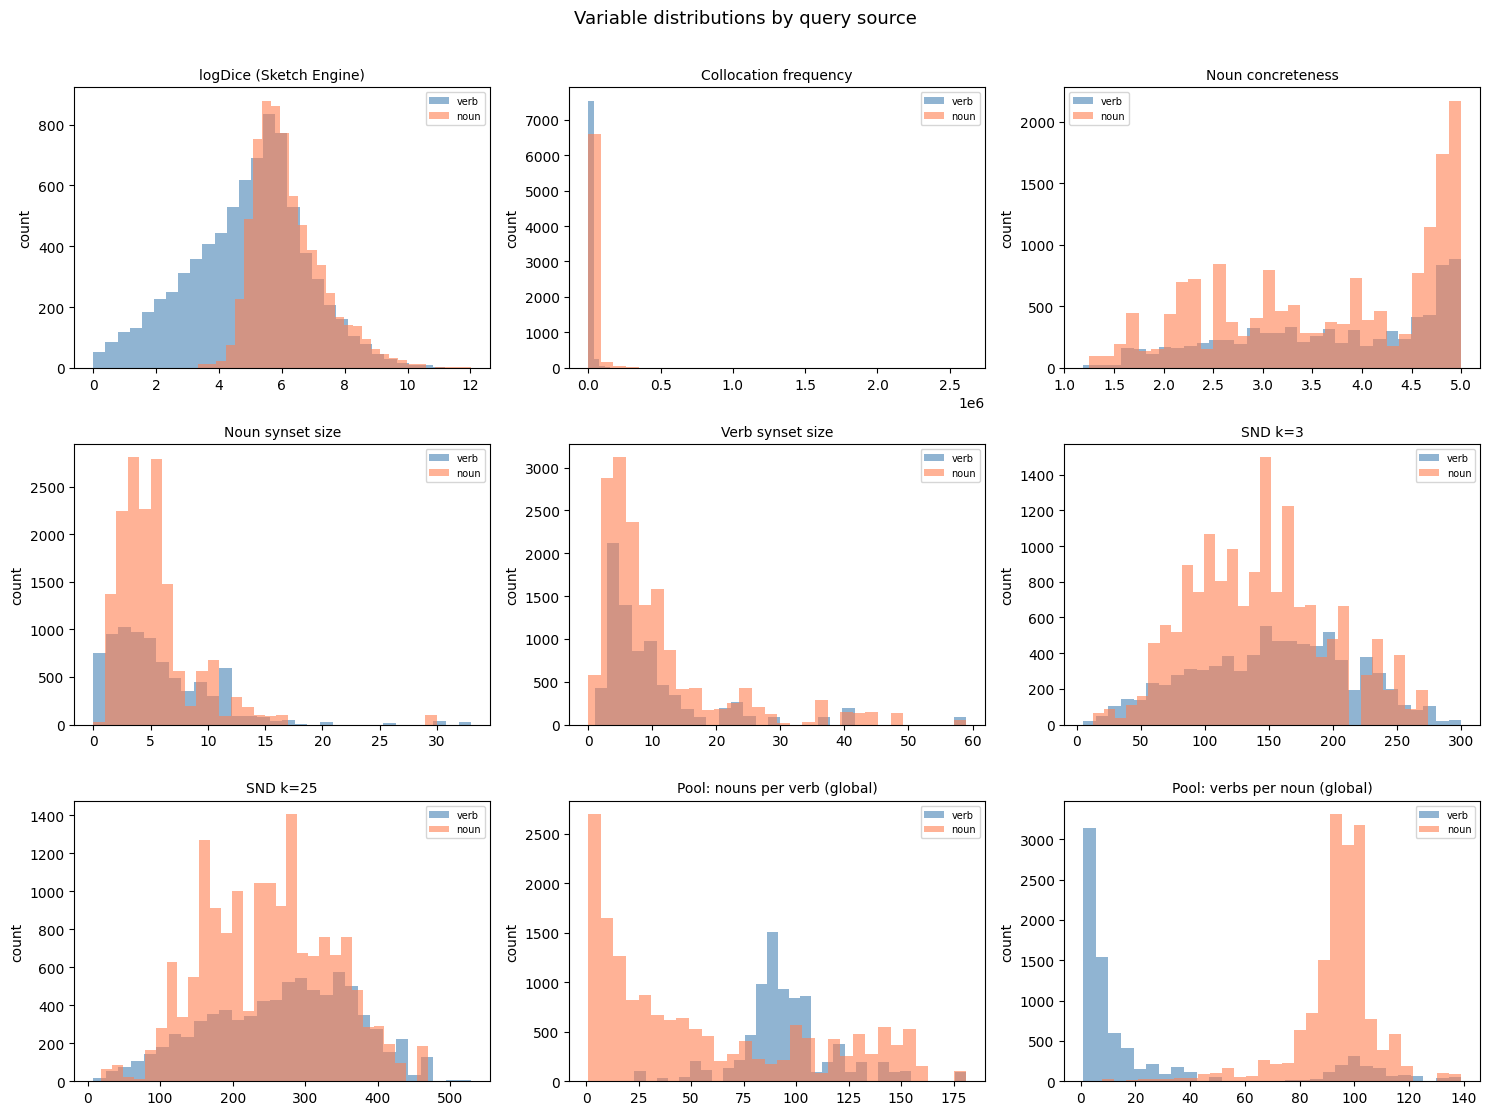

In [8]:
## 4. Distribution plots

COLORS = {'queried_by_verb': 'steelblue', 'queried_by_noun': 'coral'}
plot_cols = [
    ('logDice',                    'logDice (Sketch Engine)'),
    ('coll_freq',                  'Collocation frequency'),
    ('noun_concreteness',          'Noun concreteness'),
    ('noun_synset_len',            'Noun synset size'),
    ('verb_synset_len',            'Verb synset size'),
    ('snd3',                       'SND k=3'),
    ('snd25',                      'SND k=25'),
    ('n_nouns_for_verb_global',    'Pool: nouns per verb (global)'),
    ('n_verbs_for_noun_global',    'Pool: verbs per noun (global)'),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, (col, title) in zip(axes.ravel(), plot_cols):
    for src, color in COLORS.items():
        vals = df.loc[df['source'] == src, col].dropna()
        ax.hist(vals, bins=30, alpha=0.6, color=color, label=src.replace('queried_by_', ''))
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('count')
    ax.legend(fontsize=7)

fig.suptitle('Variable distributions by query source', fontsize=13, y=1.01)
fig.tight_layout()
dist_path = EXPORT_DIR / 'context_distribution_plots.png'
fig.savefig(dist_path, dpi=150, bbox_inches='tight')
print('Saved to', dist_path)
plt.show()

In [ ]:
## 5. SND profiles across neighbourhood sizes

snd_cols   = ['snd3', 'snd10', 'snd25', 'snd50']
snd_labels = ['k=3', 'k=10', 'k=25', 'k=50']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, src in zip(axes, ['queried_by_verb', 'queried_by_noun']):
    sub = df.loc[df['source'] == src, snd_cols].dropna()
    ax.boxplot([sub[c] for c in snd_cols], labels=snd_labels, patch_artist=True,
               boxprops=dict(facecolor=COLORS[src], alpha=0.6))
    ax.set_title(f'SND — {src.replace("queried_by_", "")}')
    ax.set_ylabel('SND score')
    ax.set_xlabel('neighbourhood size k')

fig.suptitle('Semantic neighbourhood density across k', fontsize=12)
fig.tight_layout()
snd_path = EXPORT_DIR / 'snd_profiles.png'
fig.savefig(snd_path, dpi=150, bbox_inches='tight')
print('Saved to', snd_path)
plt.show()

In [ ]:
## 6. Export

df.to_csv(EXPORT_DIR / 'combined_pairs.csv', index=False)

with open(EXPORT_DIR / 'descriptive_stats.json', 'w', encoding='utf-8') as f:
    json.dump(stats, f, indent=2)

print('Exported:')
for p in ['combined_pairs.csv', 'descriptive_stats.json',
          'context_distribution_plots.png', 'snd_profiles.png']:
    print(' -', EXPORT_DIR / p)

## Interpretation checklist for supervisors
- Are the queried-by-verb and queried-by-noun pools structurally comparable (pair counts, variable ranges)?
- Is Sketch Engine coverage acceptable for the noun-queried pairs (~57% missing)?
- Are logDice and coll_freq distributions reasonable, or are there outliers to flag?
- Are SND scores consistent across neighbourhood sizes, or do they diverge at larger k?
- Are verb/noun pool sizes balanced enough for the planned mutability contrasts?

If this audit looks good, the next notebook can compute cosine-similarity delta metrics and effect-size inference.

### Note: 3 stimuli items absent from output_verbs/output.pt

When checking which stimuli items have embeddings available in `output_verbs/output.pt`, 3 out of 190 items are missing:

| Item | Condition | Reason |
|---|---|---|
| *beat odds* | Collocation | "odds" is plurale tantum — Sketch Engine does not return it as a lemmatised noun collocate of *beat* |
| *dent cans* | Productive | "can" absent from Sketch Engine's verb-object sketch for *dent*, likely due to POS ambiguity (noun vs modal) **on Sketch Engine's end** — not filtered by our pipeline (noun-side filters only exclude nouns < 3 chars or without a concreteness rating; "can" passes both) |
| *launder clothes* | Productive | "clothes" not returned as a top collocate; *launder* returns "clothing", "garment", "linen" etc. — lemmatisation mismatch on Sketch Engine's end |

These 3 items (1 collocation, 2 productive) will be excluded from the Delta embedding analysis. The exclusion is not condition-biased and represents < 2% of the stimulus set.